## Build RNN Train/Test Datasets (n=5000 each)
This cell uses your local `toy_data` package to create reproducible sequence datasets for next-step prediction.

In [6]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step examples for each split
n_examples = 5000

# build_sequence_dataset returns length n-1 targets, so generate n_examples + 1 flips
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

# Different seeds give independent train/test draws
train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed)
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed)

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

# Optional: save datasets for reuse
out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)

train_path = out_dir / 'rnn_train_n5000.json'
test_path = out_dir / 'rnn_test_n5000.json'

with train_path.open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)

with test_path.open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved train dataset to:', train_path)
print('Saved test dataset to:', test_path)

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved train dataset to: toy_data\rnn_train_n5000.json
Saved test dataset to: toy_data\rnn_test_n5000.json


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader


class RNNWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must be the same length')
        if len(x_full) <= seq_len:
            raise ValueError('Sequence is too short for the chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y_binary = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y_binary[idx]


def load_json_if_needed(path_obj):
    with path_obj.open('r', encoding='utf-8') as f:
        return json.load(f)


train_seq_local = train_seq if 'train_seq' in globals() else load_json_if_needed(train_path)
test_seq_local = test_seq if 'test_seq' in globals() else load_json_if_needed(test_path)

seq_len = 50
batch_size = 64

train_dataset = RNNWindowDataset(train_seq_local, seq_len=seq_len)
test_dataset = RNNWindowDataset(test_seq_local, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('Train windowed dataset size:', len(train_dataset))
print('Test windowed dataset size:', len(test_dataset))
print('x_batch shape (batch, seq_len, input_dim):', tuple(x_batch.shape))
print('y_batch shape (batch, seq_len, 1):', tuple(y_batch.shape))

Train windowed dataset size: 4951
Test windowed dataset size: 4951
x_batch shape (batch, seq_len, input_dim): (64, 50, 1)
y_batch shape (batch, seq_len, 1): (64, 50, 1)


In [8]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim


class SimpleRNNPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        logits = self.head(rnn_out)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleRNNPredictor(input_size=1, hidden_size=32, num_layers=1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6737 | test_loss=0.6616 | test_acc=0.6121
Epoch 02 | train_loss=0.6675 | test_loss=0.6613 | test_acc=0.6123
Epoch 03 | train_loss=0.6667 | test_loss=0.6607 | test_acc=0.6110
Epoch 04 | train_loss=0.6664 | test_loss=0.6611 | test_acc=0.6092
Epoch 05 | train_loss=0.6661 | test_loss=0.6610 | test_acc=0.6115
Epoch 06 | train_loss=0.6658 | test_loss=0.6611 | test_acc=0.6118
Epoch 07 | train_loss=0.6654 | test_loss=0.6613 | test_acc=0.6140
Epoch 08 | train_loss=0.6650 | test_loss=0.6608 | test_acc=0.6136
Epoch 09 | train_loss=0.6646 | test_loss=0.6628 | test_acc=0.6029
Epoch 10 | train_loss=0.6640 | test_loss=0.6613 | test_acc=0.6134
Epoch 11 | train_loss=0.6634 | test_loss=0.6610 | test_acc=0.6107
Epoch 12 | train_loss=0.6630 | test_loss=0.6618 | test_acc=0.6078
Epoch 13 | train_loss=0.6624 | test_loss=0.6612 | test_acc=0.6102
Epoch 14 | train_loss=0.6615 | test_loss=0.6630 | test_acc=0.6059
Epoch 15 | train_loss=0.6604 | test_loss=0.6643 | test_acc=0.6045
Epoch 16 |

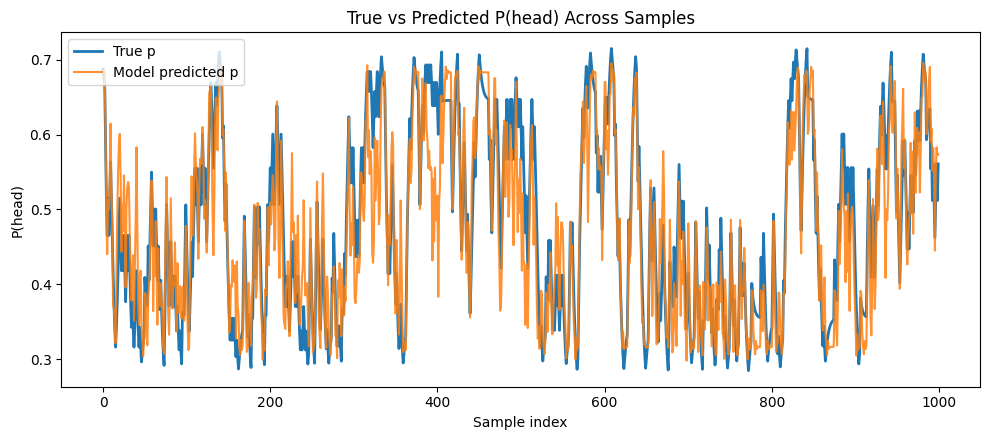

Plotted points: 1000
Saved figure to: true_vs_pred_p_over_samples_rnn_train.png
Train metrics -> MAE: 0.0369, RMSE: 0.0484, Corr: 0.9204


In [9]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
)

# Align true latent p to the same windows used by the RNN dataset.
# y_p_next has one value per next-step target, so keep values at each window's last timestep.
p_true_train_window_last = train_seq_local['y_p_next'][seq_len - 1:]

# Use the same windowed inputs used in training.
X_train_windows = train_dataset.x.cpu().numpy().tolist()

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_over_samples_rnn_train.png',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

print('Plotted points:', len(p_pred_train))
print('Saved figure to: true_vs_pred_p_over_samples_rnn_train.png')
print('Train metrics -> MAE: {:.4f}, RMSE: {:.4f}, Corr: {:.4f}'.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))

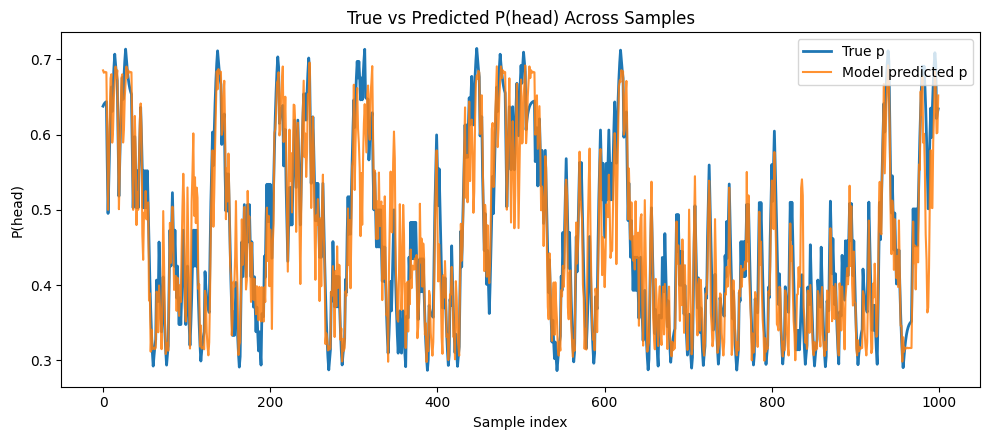

Saved figure to: true_vs_pred_p_over_samples_rnn_test.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0369  | 0.0484  | 0.9204 
Test       | 0.0362  | 0.0472  | 0.9266 


In [12]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_from_model,
    plot_true_vs_pred_p_over_samples,
    save_metrics_comparison_table_png,
)

# Align true latent p to the same windows for the test split
p_true_test_window_last = test_seq_local['y_p_next'][seq_len - 1:]

# Use the same windowed inputs from the test dataset
X_test_windows = test_dataset.x.cpu().numpy().tolist()

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_over_samples_rnn_test.png',
    show=True,
)

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
)


save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_RNN_comparison.png',
)

print('Saved figure to: true_vs_pred_p_over_samples_rnn_test.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))

In [18]:
from pathlib import Path
import json

from toy_data.adapters import build_sequence_dataset

# Desired number of supervised next-step examples for each split
n_examples = 5000

# build_sequence_dataset returns length n-1 targets, so generate n_examples + 1 flips
raw_train_n = n_examples + 1
raw_test_n = n_examples + 1

# Different seeds give independent train/test draws
train_seed = 42
test_seed = 314

train_seq = build_sequence_dataset(n=raw_train_n, seed=train_seed, mode='probabilistic')
test_seq = build_sequence_dataset(n=raw_test_n, seed=test_seed, mode='probabilistic')

assert len(train_seq['x_seq']) == n_examples
assert len(test_seq['x_seq']) == n_examples

print('Train x_seq length:', len(train_seq['x_seq']))
print('Train y_flip_next length:', len(train_seq['y_flip_next']))
print('Test x_seq length:', len(test_seq['x_seq']))
print('Test y_flip_next length:', len(test_seq['y_flip_next']))

# Optional: save datasets for reuse
out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)

train_path = out_dir / 'rnn_train_n5000_noisy.json'
test_path = out_dir / 'rnn_test_n5000_noisy.json'

with train_path.open('w', encoding='utf-8') as f:
    json.dump(train_seq, f)

with test_path.open('w', encoding='utf-8') as f:
    json.dump(test_seq, f)

print('Saved train dataset to:', train_path)
print('Saved test dataset to:', test_path)

Train x_seq length: 5000
Train y_flip_next length: 5000
Test x_seq length: 5000
Test y_flip_next length: 5000
Saved train dataset to: toy_data\rnn_train_n5000_noisy.json
Saved test dataset to: toy_data\rnn_test_n5000_noisy.json


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader


class RNNWindowDataset(Dataset):
    def __init__(self, seq_dict, seq_len=50):
        x_full = seq_dict['x_seq']
        y_full = seq_dict['y_flip_next']

        if len(x_full) != len(y_full):
            raise ValueError('x_seq and y_flip_next must be the same length')
        if len(x_full) <= seq_len:
            raise ValueError('Sequence is too short for the chosen seq_len')

        X = []
        Y = []
        for i in range(0, len(x_full) - seq_len + 1):
            X.append(x_full[i:i + seq_len])
            Y.append(y_full[i:i + seq_len])

        self.x = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        y_signed = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)
        self.y_binary = (y_signed + 1.0) / 2.0

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y_binary[idx]


def load_json_if_needed(path_obj):
    with path_obj.open('r', encoding='utf-8') as f:
        return json.load(f)


train_seq_local = train_seq if 'train_seq' in globals() else load_json_if_needed(train_path)
test_seq_local = test_seq if 'test_seq' in globals() else load_json_if_needed(test_path)

seq_len = 50
batch_size = 64

train_dataset = RNNWindowDataset(train_seq_local, seq_len=seq_len)
test_dataset = RNNWindowDataset(test_seq_local, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print('Train windowed dataset size:', len(train_dataset))
print('Test windowed dataset size:', len(test_dataset))
print('x_batch shape (batch, seq_len, input_dim):', tuple(x_batch.shape))
print('y_batch shape (batch, seq_len, 1):', tuple(y_batch.shape))

Train windowed dataset size: 4951
Test windowed dataset size: 4951
x_batch shape (batch, seq_len, input_dim): (64, 50, 1)
y_batch shape (batch, seq_len, 1): (64, 50, 1)


In [20]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim


class SimpleRNNPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        logits = self.head(rnn_out)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleRNNPredictor(input_size=1, hidden_size=32, num_layers=1).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            test_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6767 | test_loss=0.6817 | test_acc=0.5698
Epoch 02 | train_loss=0.6713 | test_loss=0.6818 | test_acc=0.5689
Epoch 03 | train_loss=0.6711 | test_loss=0.6819 | test_acc=0.5699
Epoch 04 | train_loss=0.6711 | test_loss=0.6824 | test_acc=0.5666
Epoch 05 | train_loss=0.6709 | test_loss=0.6825 | test_acc=0.5685
Epoch 06 | train_loss=0.6706 | test_loss=0.6828 | test_acc=0.5678
Epoch 07 | train_loss=0.6705 | test_loss=0.6826 | test_acc=0.5636
Epoch 08 | train_loss=0.6702 | test_loss=0.6837 | test_acc=0.5656
Epoch 09 | train_loss=0.6697 | test_loss=0.6836 | test_acc=0.5679
Epoch 10 | train_loss=0.6686 | test_loss=0.6848 | test_acc=0.5623
Epoch 11 | train_loss=0.6672 | test_loss=0.6859 | test_acc=0.5596
Epoch 12 | train_loss=0.6658 | test_loss=0.6877 | test_acc=0.5588
Epoch 13 | train_loss=0.6644 | test_loss=0.6903 | test_acc=0.5563
Epoch 14 | train_loss=0.6624 | test_loss=0.6913 | test_acc=0.5539
Epoch 15 | train_loss=0.6603 | test_loss=0.6956 | test_acc=0.5497
Epoch 16 |

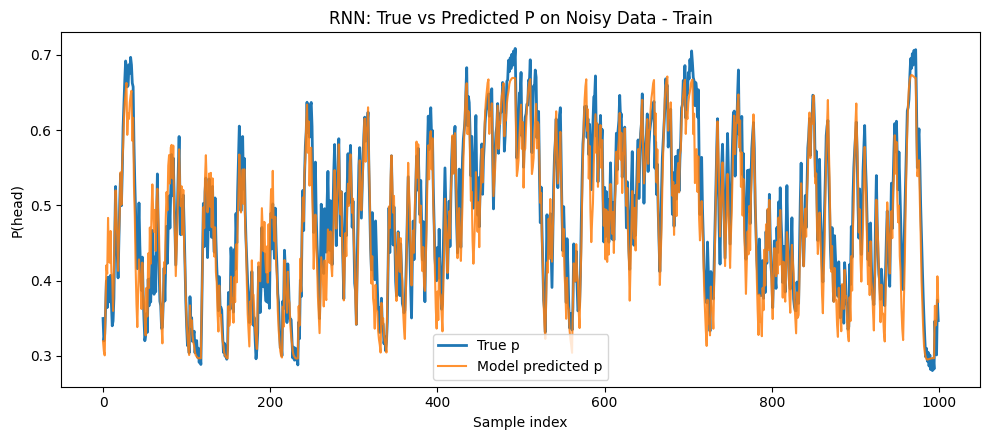

Plotted points: 1000
Saved figure to: true_vs_pred_p_over_samples_rnn_train_noisy.png
Train metrics -> MAE: 0.0240, RMSE: 0.0303, Corr: 0.9583


In [21]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_torch_sequence,
    plot_true_vs_pred_p_over_samples_torch_sequence,
)

# Align true latent p to the same windows used by the RNN dataset.
# y_p_next has one value per next-step target, so keep values at each window's last timestep.
p_true_train_window_last = train_seq_local['y_p_next'][seq_len - 1:]

# Use the same windowed inputs used in training.
X_train_windows = train_dataset.x.cpu().numpy().tolist()

p_pred_train = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_over_samples_rnn_train_noisy.png',
    title='RNN: True vs Predicted P on Noisy Data - Train',
    show=True,
 )



print('Plotted points:', len(p_pred_train))
print('Saved figure to: true_vs_pred_p_over_samples_rnn_train_noisy.png')
print('Train metrics -> MAE: {:.4f}, RMSE: {:.4f}, Corr: {:.4f}'.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))

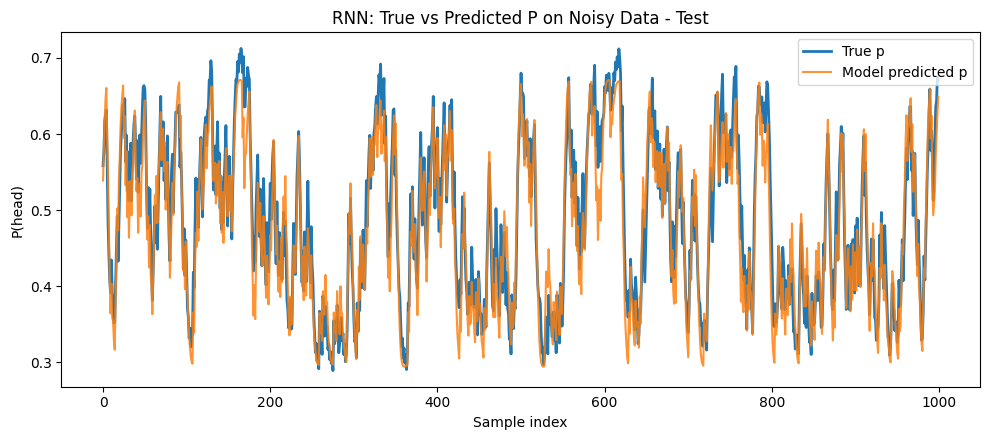

Saved figure to: true_vs_pred_p_over_samples_rnn_test_noisy.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0287  | 0.0363  | 0.9495 
Test       | 0.0300  | 0.0374  | 0.9467 


In [22]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_from_model,
    plot_true_vs_pred_p_over_samples,
    save_metrics_comparison_table_png,
)

# Align true latent p to the same windows for the test split
p_true_test_window_last = test_seq_local['y_p_next'][seq_len - 1:]

# Use the same windowed inputs from the test dataset
X_test_windows = test_dataset.x.cpu().numpy().tolist()

p_pred_test = plot_true_vs_pred_p_over_samples_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
    max_points=1000,
    save_path='true_vs_pred_p_over_samples_rnn_test_noisy.png',
    title='RNN: True vs Predicted P on Noisy Data - Test',
    show=True,
)

metrics_train = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_train_windows,
    p_true=p_true_train_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
 )

metrics_test = compute_true_vs_pred_metrics_torch_sequence(
    model=model,
    X=X_test_windows,
    p_true=p_true_test_window_last,
    device=str(device),
    apply_sigmoid=True,
    use_last_timestep=True,
)


save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_RNN_comparison_noisy.png',
)

print('Saved figure to: true_vs_pred_p_over_samples_rnn_test_noisy.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))